In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carica il verde urbano
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json")
print(f"Aree verdi caricate: {len(green)}")
print(green.columns.tolist())

C:\Users\andre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carica il verde urbano ignorando geometrie non valide
green = gpd.read_file(
    r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json",
    on_invalid="ignore"
)
print(f"Aree verdi caricate: {len(green)}")
print(green.columns.tolist())

Aree verdi caricate: 125
['Stadsdeel', 'Naam', 'Stadspark', 'Oppervlakte_m2', 'geometry']


In [3]:
green.head()

,Stadsdeel,Naam,Stadspark,Oppervlakte_m2,geometry
0,Nieuw-West,Gerbrandypark,N,71578,"POLYGON ((4.82679 52.37905, 4.82681 52.37901, ..."
1,Zuid,Park Schinkeleilanden,J,17968,"MULTIPOLYGON (((4.8505 52.34452, 4.85053 52.34..."
2,Zuid,Amstelpark,J,438723,"MULTIPOLYGON (((4.89062 52.32876, 4.89061 52.3..."
3,Zuid,`t Kleine Loopveld,N,166447,"MULTIPOLYGON (((4.89212 52.32256, 4.89223 52.3..."
4,Zuid,Sarphatipark,J,42087,"POLYGON ((4.89856 52.35481, 4.89895 52.35431, ..."


In [4]:
top10 = green[['Naam', 'Stadsdeel', 'Oppervlakte_m2']]\
    .sort_values('Oppervlakte_m2', ascending=False)\
    .head(10)

print(top10.to_string(index=False))

              Naam  Stadsdeel  Oppervlakte_m2
   Amsterdamse Bos Amstelveen         9192494
        De Bretten Nieuw-West         1671833
         Diemerbos   Zuidoost         1275032
       Gaasperpark   Zuidoost         1207889
        Diemerpark       Oost          928864
       Gaasperzoom   Zuidoost          881942
         Geuzenbos Nieuw-West          781586
      Bijlmerweide   Zuidoost          636053
     Lutkemeerpark Nieuw-West          598595
Nelson Mandelapark   Zuidoost          550892


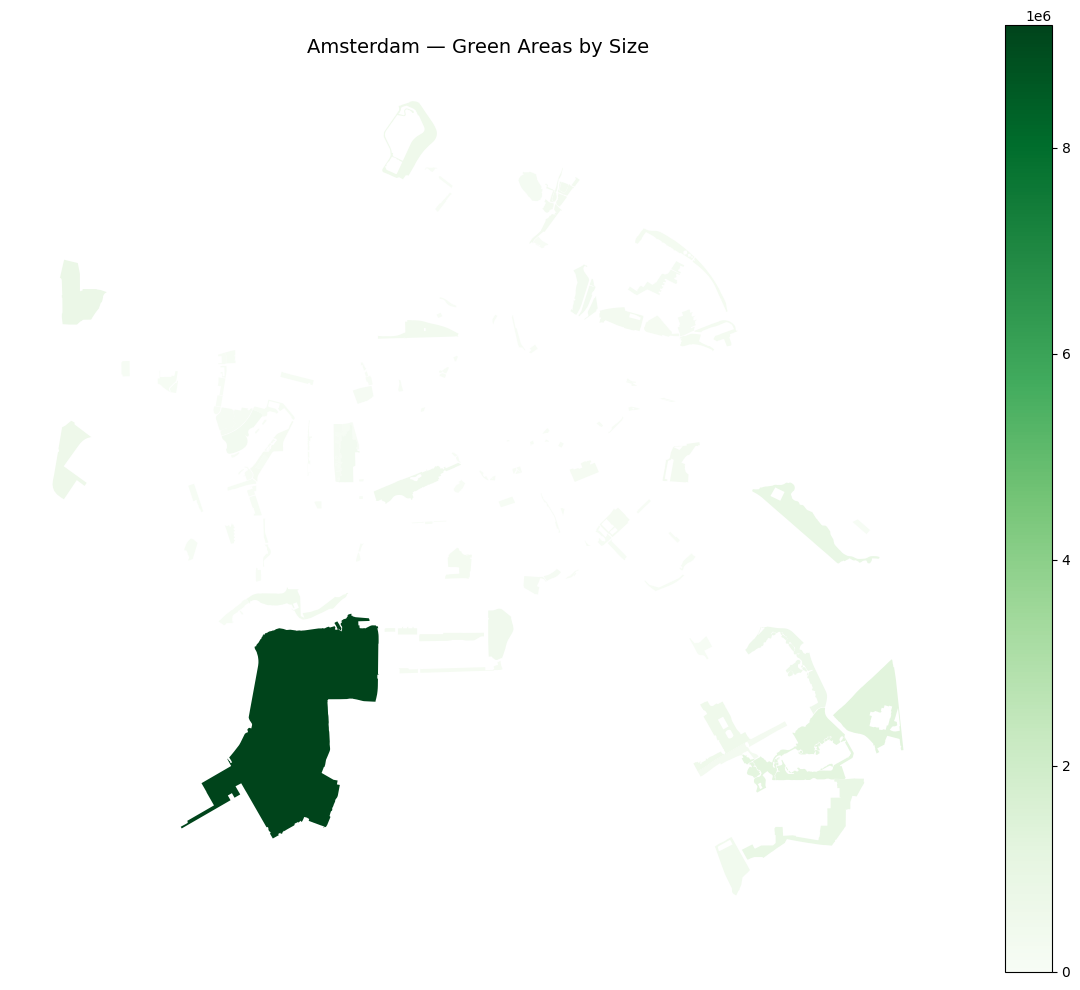

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

green.plot(
    column='Oppervlakte_m2',
    cmap='Greens',
    legend=True,
    ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Amsterdam — Green Areas by Size', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_green.png', dpi=150, bbox_inches='tight')
plt.show()

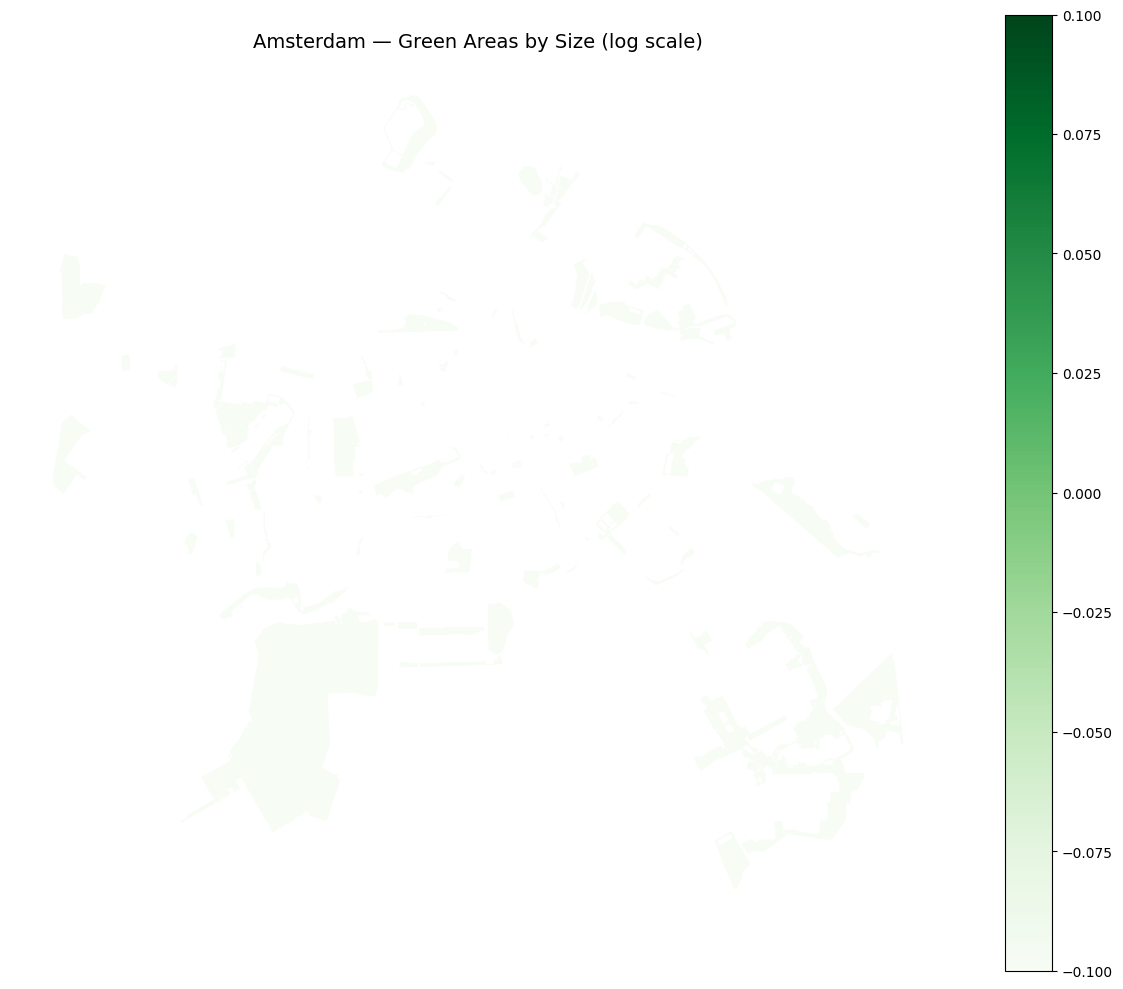

In [6]:
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

green_copy = green.copy()
green_copy['verde_log'] = np.log10(green_copy['Oppervlakte_m2'])

green_copy.plot(
    column='verde_log',
    cmap='Greens',
    legend=True,
    ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Amsterdam — Green Areas by Size (log scale)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_green_log.png', dpi=150, bbox_inches='tight')
plt.show()

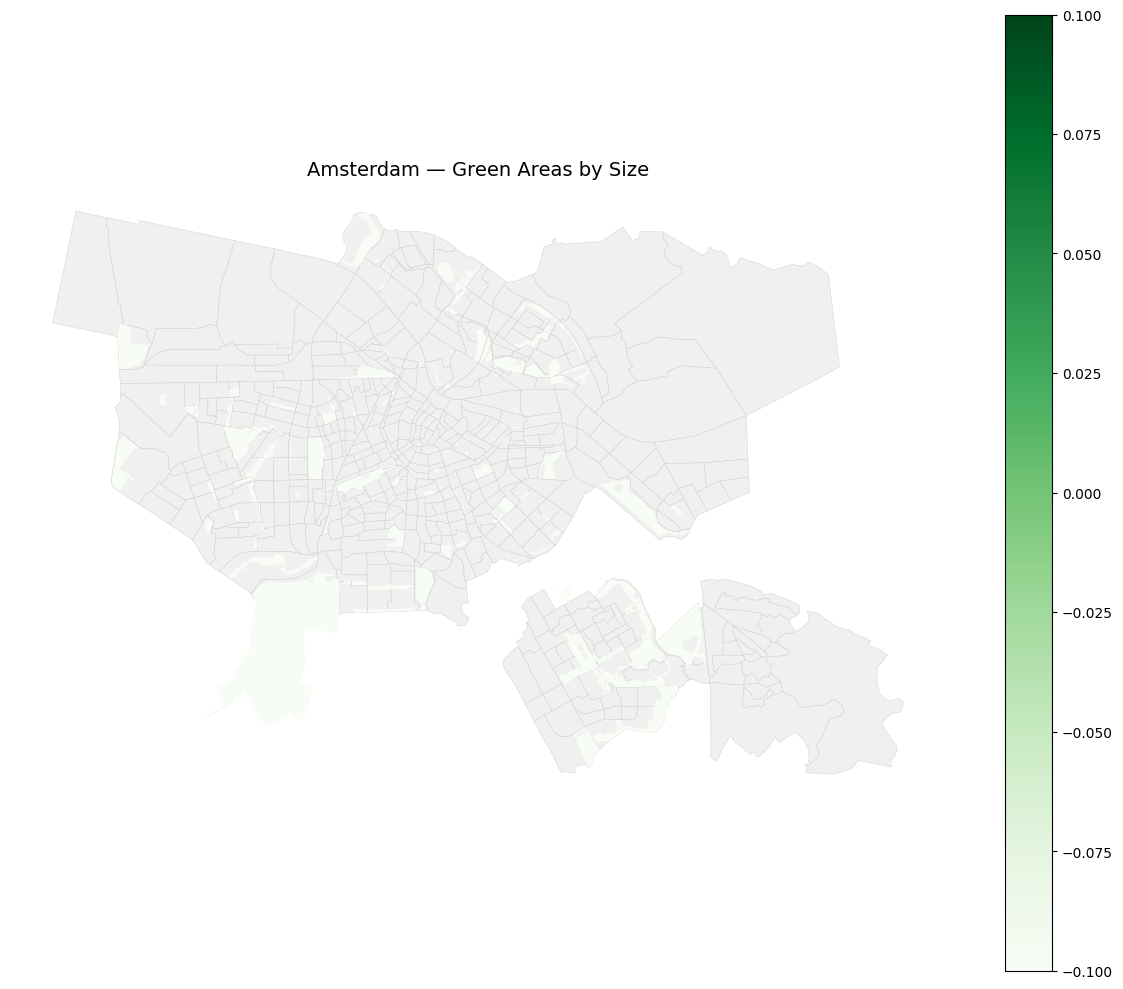

In [7]:
# Carichiamo i buurten come sfondo
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten = buurten.to_crs(green.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Prima disegna i quartieri come sfondo grigio
buurten.plot(
    ax=ax,
    color='#f0f0f0',
    edgecolor='#cccccc',
    linewidth=0.3
)

# Poi sovrapponi i parchi colorati
green_copy.plot(
    column='verde_log',
    cmap='Greens',
    legend=True,
    ax=ax
)

ax.set_title('Amsterdam — Green Areas by Size', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_green_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
verde_per_stadsdeel = green.groupby('Stadsdeel')['Oppervlakte_m2'].sum()\
    .sort_values(ascending=False)\
    .reset_index()

verde_per_stadsdeel.columns = ['Stadsdeel', 'Verde_totale_m2']
verde_per_stadsdeel['Verde_km2'] = (verde_per_stadsdeel['Verde_totale_m2'] / 1_000_000).round(2)

print(verde_per_stadsdeel.to_string(index=False))

 Stadsdeel  Verde_totale_m2  Verde_km2
Amstelveen          9192494       9.19
Nieuw-West          5862203       5.86
  Zuidoost          5251325       5.25
     Noord          2726583       2.73
      Oost          1849505       1.85
      Zuid          1819623       1.82
      West           557488       0.56
    Diemen            94902       0.09
   Centrum            82263       0.08


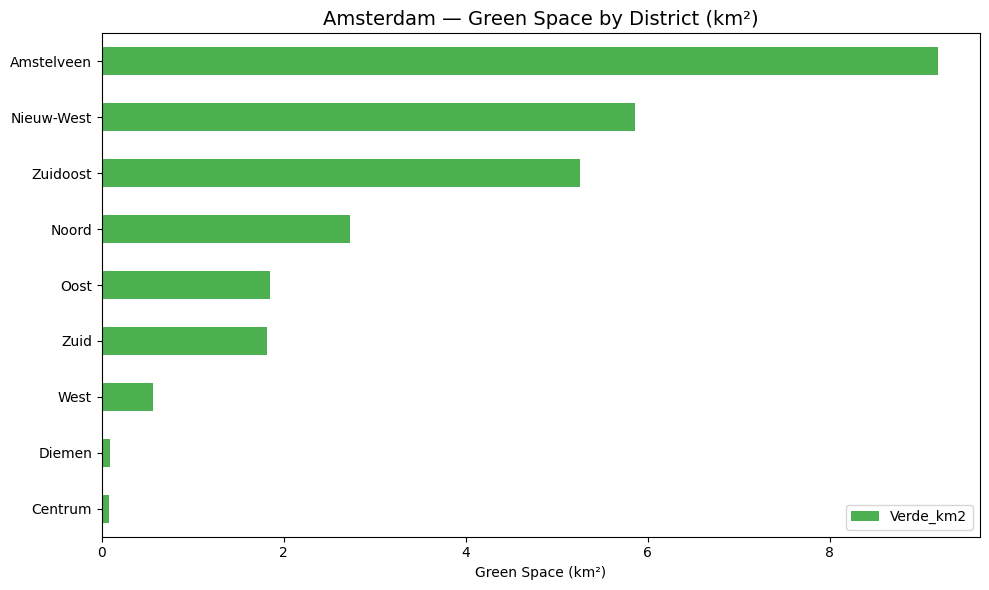

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

verde_per_stadsdeel.plot(
    kind='barh',
    x='Stadsdeel',
    y='Verde_km2',
    color='#4CAF50',
    ax=ax
)

ax.set_title('Amsterdam — Green Space by District (km²)', fontsize=14)
ax.set_xlabel('Green Space (km²)')
ax.set_ylabel('')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('amsterdam_green_chart.png', dpi=150, bbox_inches='tight')
plt.show()